### **Development of Surrogate Machine Learning Models for a Binary Distillation Column**
 **FOSSEE Summer Fellowship 2026**

Lead By: Samarth

University: Adani University



DWSIM are highly accurate but computationally expensive for real-time use. This project develops a surrogate model of a 30-stage Benzene and p-Xylene distillation column. By using Machine Learning, we aim to reduce prediction times from seconds to milliseconds without losing thermodynamic precision.

We are loading a dataset of 2,700 samples generated via DWSIM sensitivity studies. The data covers thermal, mass, and compositional regimes to ensure the model understands how the column behaves under different stress levels.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

# Function to load and standardize DWSIM CSV files
def clean_and_fill(file_path, source):
    df = pd.read_csv(file_path)
    # Remove hidden spaces from DWSIM column headers
    df.columns = df.columns.str.strip()

    # Map long DWSIM names to simple variables
    rename_map = {
        'DCOL-1 - Condenser_Specification_Value': 'Reflux',
        'Feed - Temperature (K)': 'Temp',
        'DCOL-1 - Reboiler_Specification_Value': 'Bottoms_Rate',
        'Feed - Molar Fraction (Mixture) / Benzene': 'Feed_Comp',
        'Distillate - Molar Fraction (Liquid 1) / Benzene ()': 'xD',
        'Bottoms - Molar Fraction (Liquid 1) / Benzene ()': 'xB',
        'QC - Energy Flow (kW)': 'QC',
        'QR - Energy Flow (kW)': 'QR',
        'Feed - Molar Fraction (Vapor) ()': 'Vapor_Frac'
    }
    df = df.rename(columns=rename_map)

    # Fill constant values for parameters that weren't varied in specific studies
    if source == 'thermal':
        df['Bottoms_Rate'], df['Feed_Comp'] = 5.5, 0.5
    elif source == 'mass':
        df['Temp'], df['Feed_Comp'] = 298.0, 0.5
    elif source == 'comp':
        df['Temp'], df['Bottoms_Rate'] = 298.0, 5.5

    return df[['Reflux', 'Temp', 'Bottoms_Rate', 'Feed_Comp', 'Vapor_Frac', 'xD', 'xB', 'QC', 'QR']]

# Combine all 2,700 rows from the three studies
master_df = pd.concat([
    clean_and_fill('/content/sample_data/thermal_v2.csv', 'thermal'),
    clean_and_fill('/content/sample_data/mass_v2.csv', 'mass'),
    clean_and_fill('/content/sample_data/composition_v2.csv', 'comp')
], ignore_index=True).dropna()

Dataset finalized with 2700 valid physics rows.


 **Reflux-to-Bottoms Ratio ($RF\_Ratio$)**

We are introducing a calculated feature: $RF\_Ratio = \frac{Reflux}{Bottoms\_Rate}$. This helps the models recognize the relationship between internal traffic and reboiler load more efficiently than raw values alone.

In [ ]:
# Apply Physics Filter: Benzene is lighter, so xD must be greater than xB
master_df = master_df[master_df['xD'] > master_df['xB']]

# Feature Engineering: Reflux-to-Bottoms Ratio (Crucial for AI learning)
master_df['RF_Ratio'] = master_df['Reflux'] / (master_df['Bottoms_Rate'] + 1e-7)

print(f"Dataset finalized with {len(master_df)} valid physics rows.")

In [ ]:
# Define Inputs (X) and Targets (Y)
features = ['Reflux', 'Temp', 'Bottoms_Rate', 'Feed_Comp', 'Vapor_Frac', 'RF_Ratio']
targets = ['xD', 'xB', 'QC', 'QR']

X = master_df[features]
y = master_df[targets]

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data so all features have equal mathematical weight
scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)
y_test_s = scaler_y.transform(y_test)

print("Scaling complete. Training samples:", len(X_train_s))

Scaling complete. Training samples: 2160


We evaluate the models based on $R^2$, MAE, and RMSE. While tree-based models often show the highest scores, we are looking for the model that best represents the continuous nature of distillation.

We are benchmarking four distinct algorithms to find the best balance between speed and physical accuracy:


**XGBoost:** Excellent for the high-purity plateau.


**Random Forest:** Used for stability against numerical outliers.


**SVR (RBF Kernel):** Testing if a high-dimensional surface can map the SRK equations.


**Artificial Neural Network (ANN)**: Designed to learn the interconnected Multi-Input Multi-Output physics of the system.

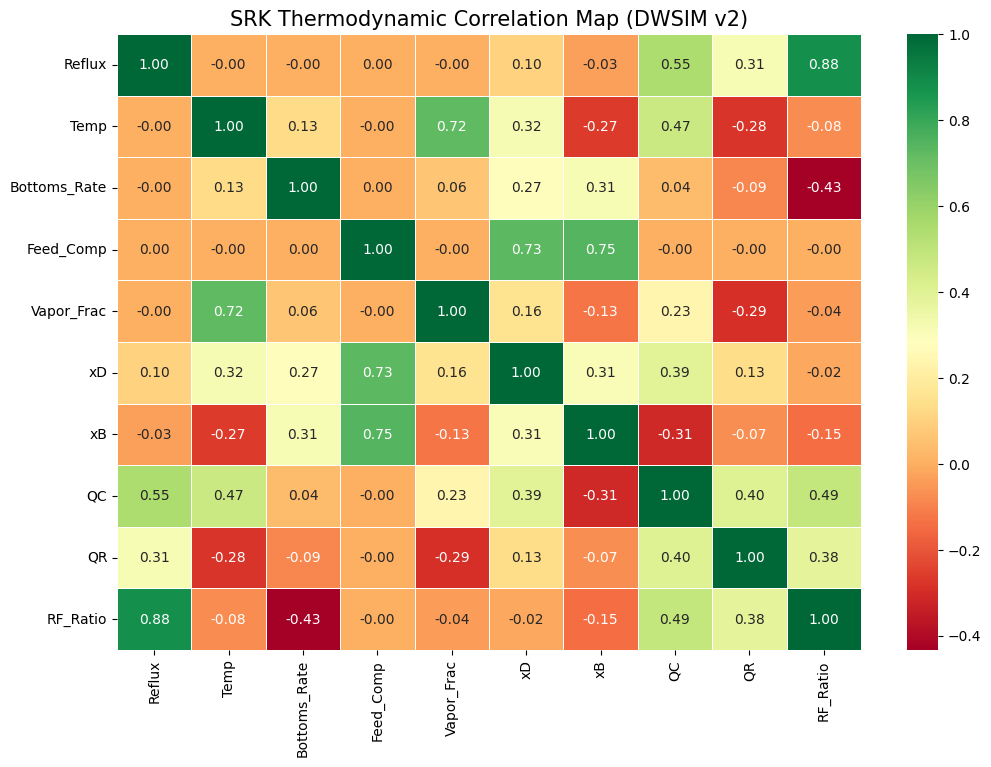

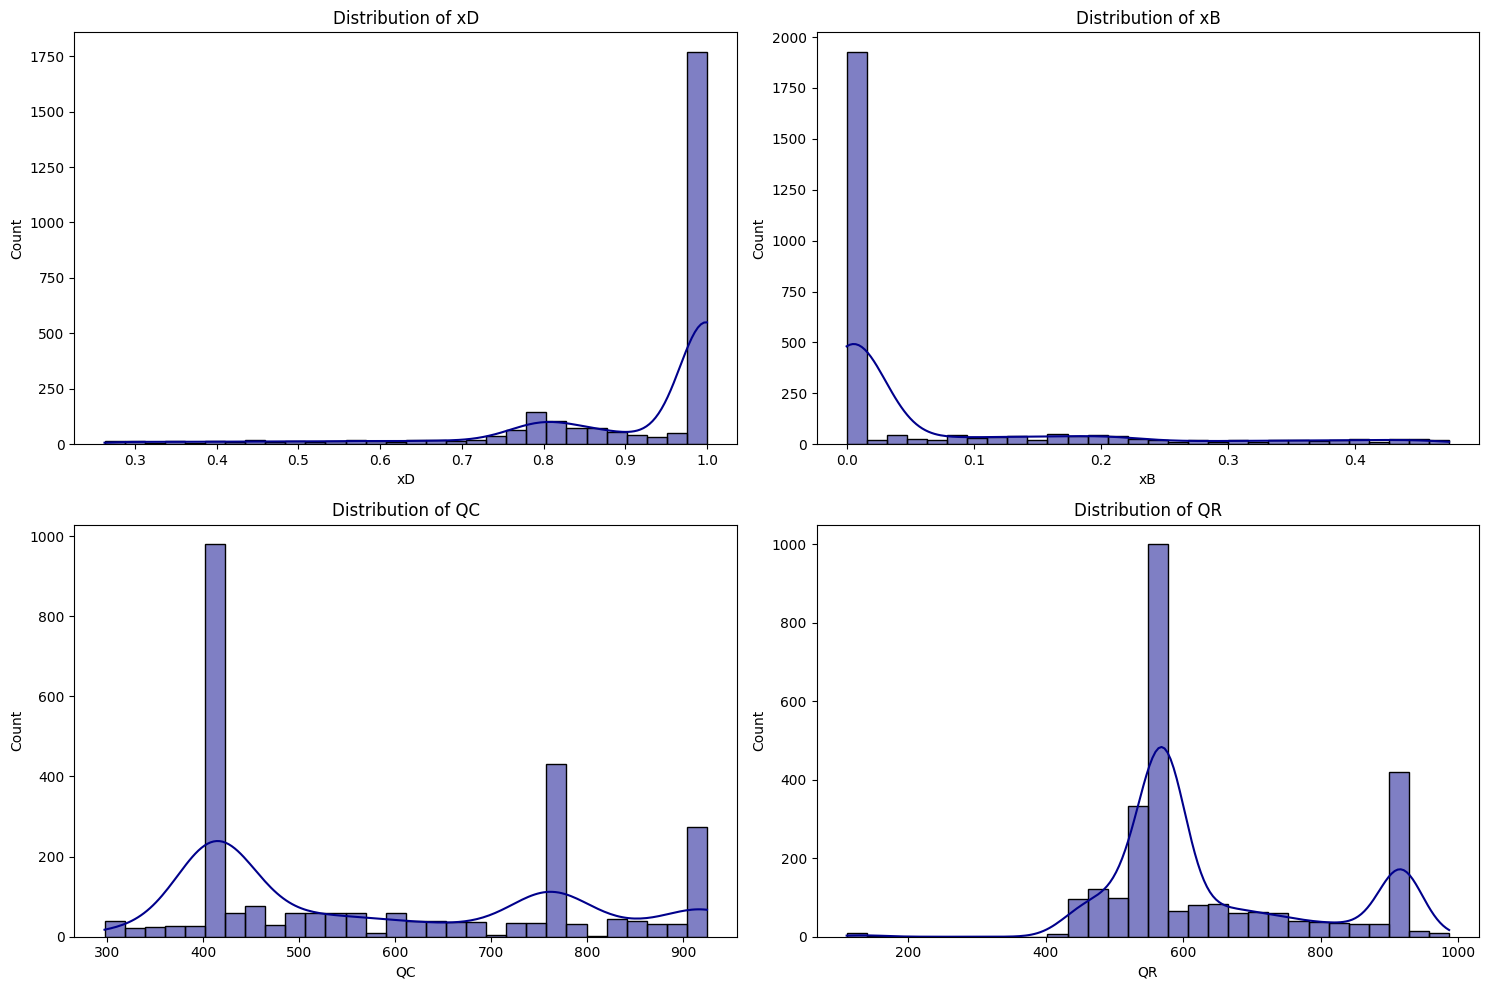

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(master_df.corr(), annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('SRK Thermodynamic Correlation Map (DWSIM v2)', fontsize=15)
plt.show()

# 2. Diversity Check (Histograms)
plt.figure(figsize=(15, 10))
cols_to_plot = ['xD', 'xB', 'QC', 'QR']
for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 2, i+1)
    sns.histplot(master_df[col], bins=30, kde=True, color='darkblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**XGBoost**

--- XGBOOST INDIVIDUAL PERFORMANCE ---
R2 Score: 0.9910
MAE: 0.0151
RMSE: 0.0933


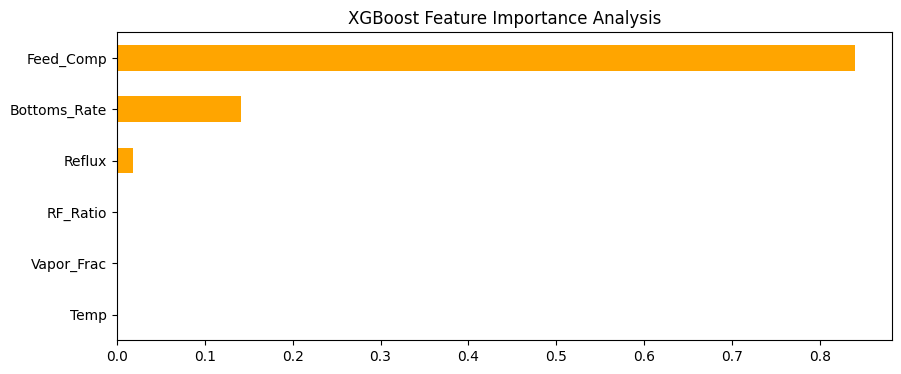

In [ ]:
from xgboost import XGBRegressor

# Train Model
xgb_model = MultiOutputRegressor(XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05))
xgb_model.fit(X_train_s, y_train_s)
p_xgb = xgb_model.predict(X_test_s)

# Individual Scoring
print("--- XGBOOST INDIVIDUAL PERFORMANCE ---")
print(f"R2 Score: {r2_score(y_test_s, p_xgb):.4f}")
print(f"MAE: {mean_absolute_error(y_test_s, p_xgb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_s, p_xgb)):.4f}")

# Feature Analysis (Requirement: Input Analysis)
importances = xgb_model.estimators_[0].feature_importances_
plt.figure(figsize=(10, 4))
pd.Series(importances, index=features).sort_values().plot(kind='barh', color='orange')
plt.title("XGBoost Feature Importance Analysis")
plt.show()

**Random Forest**

--- RANDOM FOREST INDIVIDUAL PERFORMANCE ---
R2 Score: 0.9962
MAE: 0.0110
RMSE: 0.0608


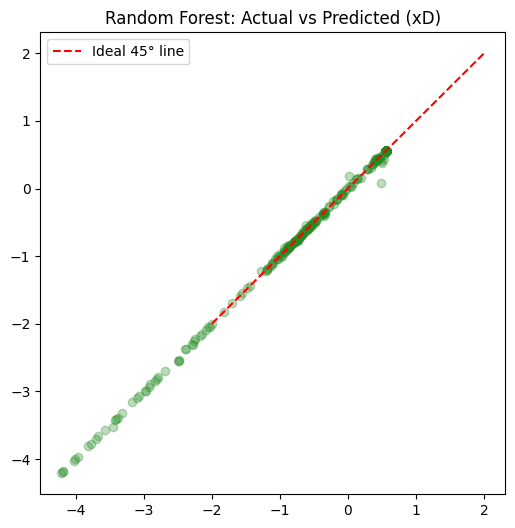

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Train Model
rf_model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100))
rf_model.fit(X_train_s, y_train_s)
p_rf = rf_model.predict(X_test_s)

# Individual Scoring
print("--- RANDOM FOREST INDIVIDUAL PERFORMANCE ---")
print(f"R2 Score: {r2_score(y_test_s, p_rf):.4f}")
print(f"MAE: {mean_absolute_error(y_test_s, p_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_s, p_rf)):.4f}")

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test_s[:, 0], p_rf[:, 0], alpha=0.3, color='forestgreen')
plt.plot([-2, 2], [-2, 2], 'r--', label='Ideal 45° line')
plt.title("Random Forest: Actual vs Predicted (xD)")
plt.legend(); plt.show()

**SVR**

--- SVR INDIVIDUAL PERFORMANCE ---
R2 Score: 0.8872
MAE: 0.1266
RMSE: 0.3330


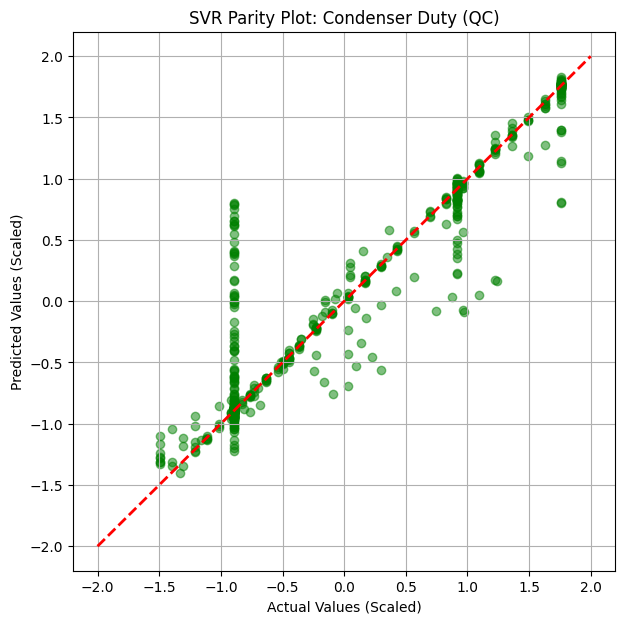

In [10]:
from sklearn.svm import SVR

# Train Model
svr_model = MultiOutputRegressor(SVR(kernel='rbf', C=100, epsilon=0.01))
svr_model.fit(X_train_s, y_train_s)
p_svr = svr_model.predict(X_test_s)

# Individual Scoring
print("--- SVR INDIVIDUAL PERFORMANCE ---")
print(f"R2 Score: {r2_score(y_test_s, p_svr):.4f}")
print(f"MAE: {mean_absolute_error(y_test_s, p_svr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_s, p_svr)):.4f}")

# 4. Parity Plot for Energy (QC)
plt.figure(figsize=(7, 7))
plt.scatter(y_test_s[:, 2], p_svr[:, 2], alpha=0.5, color='green')
plt.plot([-2, 2], [-2, 2], 'r--', lw=2)
plt.title('SVR Parity Plot: Condenser Duty (QC)')
plt.xlabel('Actual Values (Scaled)')
plt.ylabel('Predicted Values (Scaled)')
plt.grid(True)
plt.show()

**ANN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
--- ANN INDIVIDUAL PERFORMANCE ---
R2 Score: 0.9880
MAE: 0.0473
RMSE: 0.1081


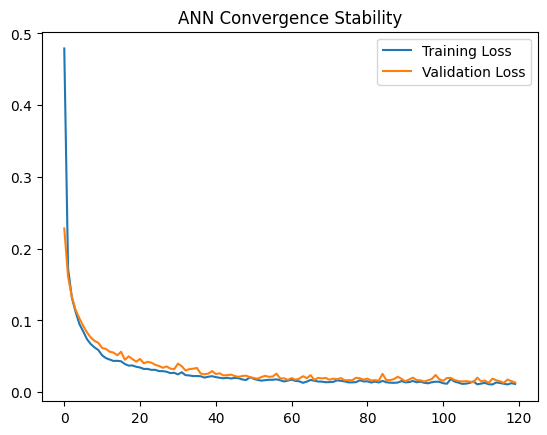

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define Architecture
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(6,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(4) # Output: xD, xB, QC, QR
])

# Compile and Train
ann_model.compile(optimizer='adam', loss='mse')
history = ann_model.fit(X_train_s, y_train_s, epochs=120, validation_split=0.2, verbose=0)
p_ann = ann_model.predict(X_test_s)

# Individual Scoring
print("--- ANN INDIVIDUAL PERFORMANCE ---")
print(f"R2 Score: {r2_score(y_test_s, p_ann):.4f}")
print(f"MAE: {mean_absolute_error(y_test_s, p_ann):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_s, p_ann)):.4f}")

# Plot Training Stability
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("ANN Convergence Stability")
plt.legend(); plt.show()

**Final Comparison**

--- FINAL BENCHMARKING LEADERBOARD ---
           Model  R2_Score  MAE_Error  RMSE_Error
1  Random Forest  0.996206   0.011036    0.060783
0        XGBoost  0.990996   0.015062    0.093283
3            ANN  0.988012   0.047251    0.108125
2            SVR  0.887194   0.126642    0.332994


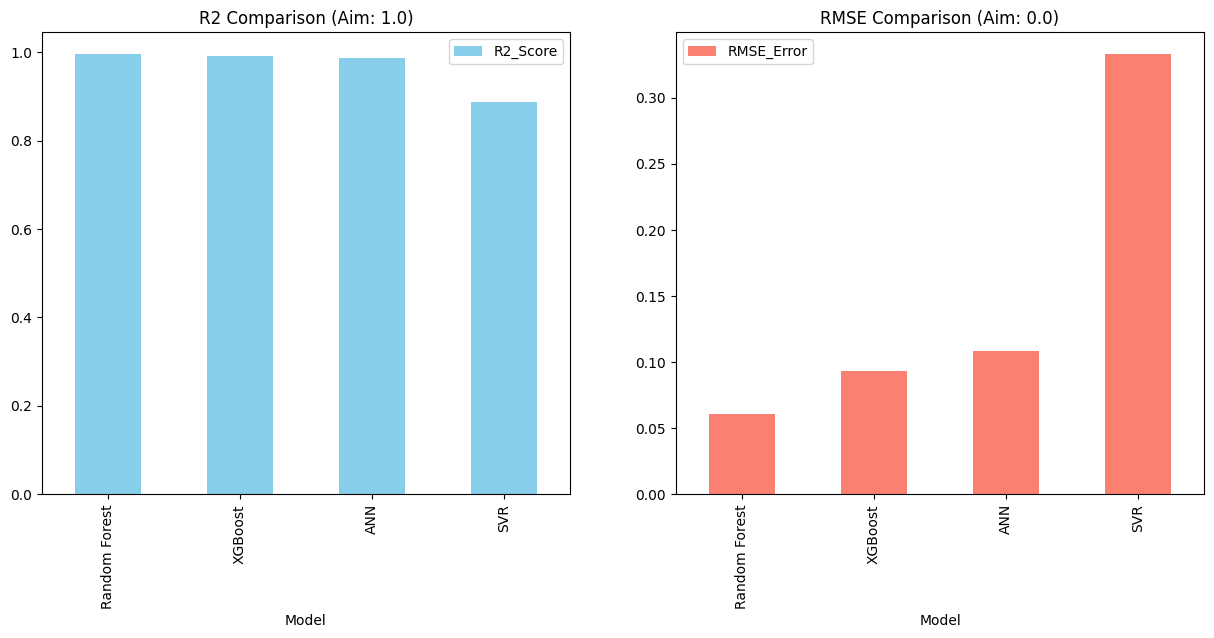

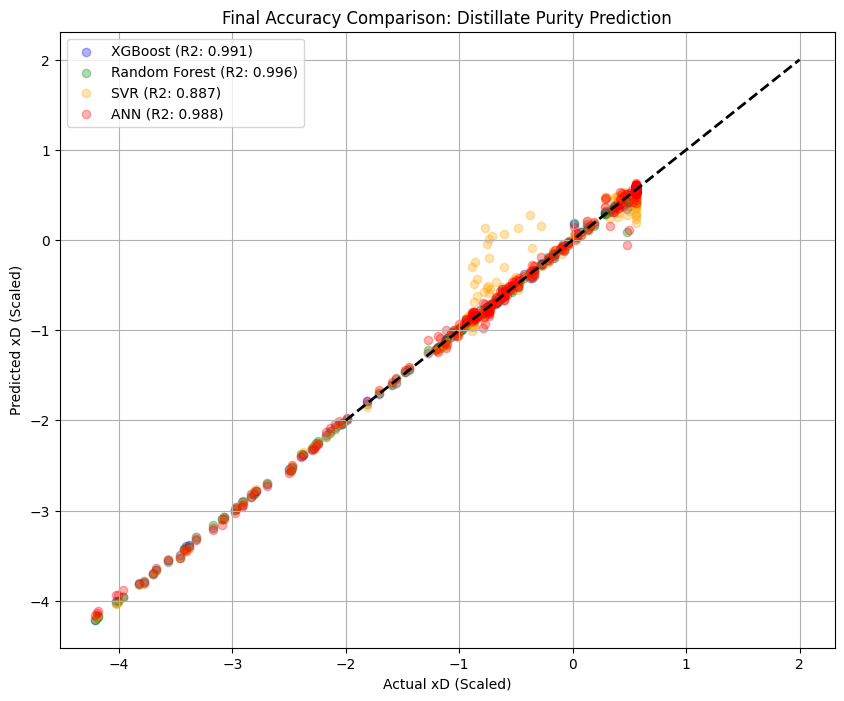

In [12]:
all_preds = {'XGBoost': p_xgb, 'Random Forest': p_rf, 'SVR': p_svr, 'ANN': p_ann}
final_results = []

for name, p in all_preds.items():
    r2 = r2_score(y_test_s, p)
    mae = mean_absolute_error(y_test_s, p)
    rmse = np.sqrt(mean_squared_error(y_test_s, p))
    final_results.append({'Model': name, 'R2_Score': r2, 'MAE_Error': mae, 'RMSE_Error': rmse})

# Create Comparison Dataframe
leaderboard = pd.DataFrame(final_results).sort_values(by='R2_Score', ascending=False)
print("--- FINAL BENCHMARKING LEADERBOARD ---")
print(leaderboard)

# Multi-Plot Accuracy Comparison
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
leaderboard.plot(x='Model', y='R2_Score', kind='bar', ax=ax[0], color='skyblue', title='R2 Comparison (Aim: 1.0)')
leaderboard.plot(x='Model', y='RMSE_Error', kind='bar', ax=ax[1], color='salmon', title='RMSE Comparison (Aim: 0.0)')
plt.show()

# Final Parity Comparison (xD Purity)
plt.figure(figsize=(10, 8))
colors = {'XGBoost': 'blue', 'Random Forest': 'green', 'SVR': 'orange', 'ANN': 'red'}
for name, p in all_preds.items():
    plt.scatter(y_test_s[:, 0], p[:, 0], label=f"{name} (R2: {r2_score(y_test_s, p):.3f})", alpha=0.3, color=colors[name])

plt.plot([-2, 2], [-2, 2], 'k--', lw=2)
plt.title("Final Accuracy Comparison: Distillate Purity Prediction")
plt.xlabel("Actual xD (Scaled)"); plt.ylabel("Predicted xD (Scaled)")
plt.legend(); plt.grid(True); plt.show()

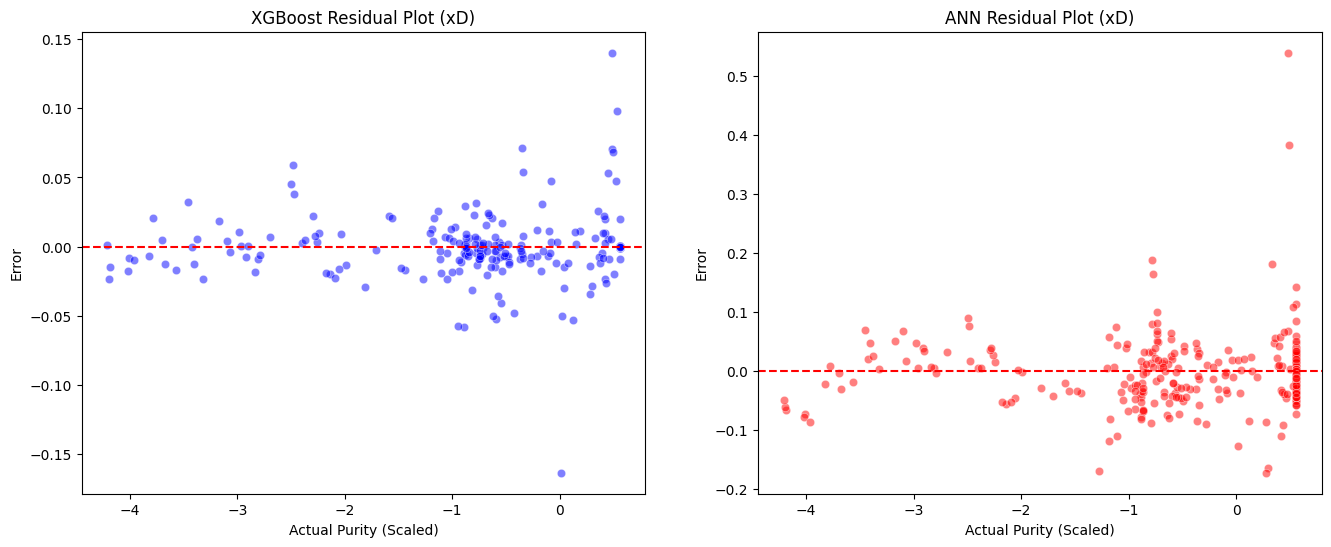

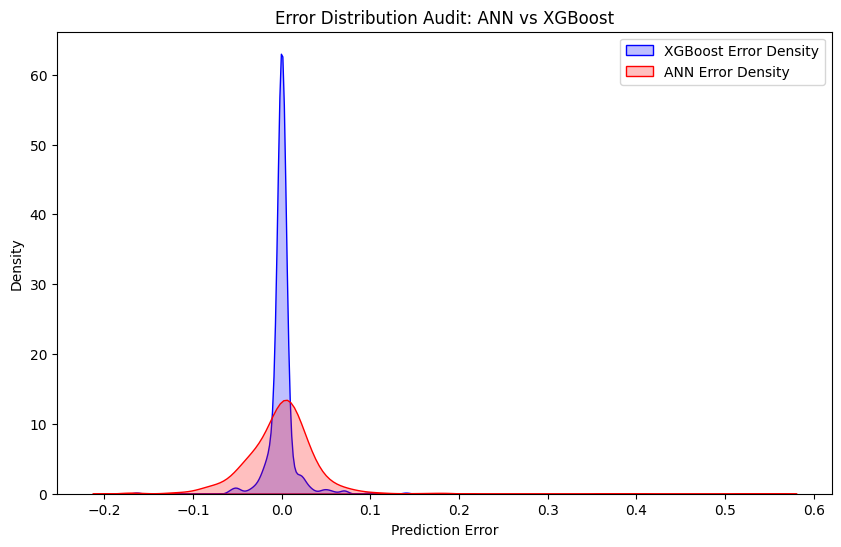

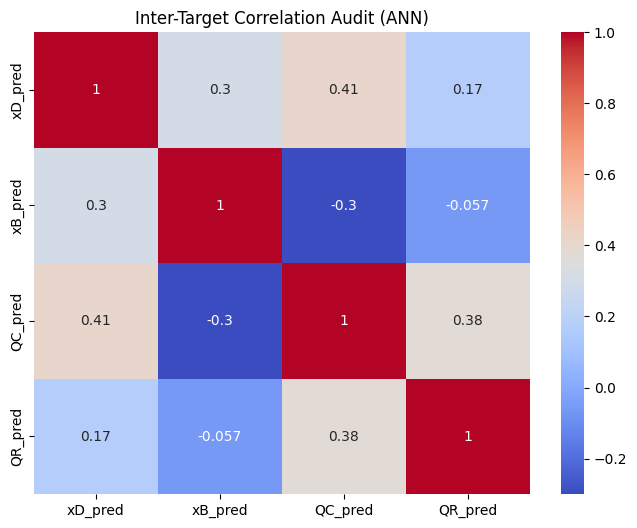

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Residual Analysis Plot (Comparing XGBoost vs ANN)
# We look at the 'xD' Purity errors specifically
res_xgb = y_test_s[:, 0] - p_xgb[:, 0]
res_ann = y_test_s[:, 0] - p_ann[:, 0]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost Residuals
sns.scatterplot(x=y_test_s[:, 0], y=res_xgb, ax=ax[0], color='blue', alpha=0.5)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title("XGBoost Residual Plot (xD)")
ax[0].set_xlabel("Actual Purity (Scaled)")
ax[0].set_ylabel("Error")

# ANN Residuals
sns.scatterplot(x=y_test_s[:, 0], y=res_ann, ax=ax[1], color='red', alpha=0.5)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title("ANN Residual Plot (xD)")
ax[1].set_xlabel("Actual Purity (Scaled)")
ax[1].set_ylabel("Error")

plt.show()

# 2. Error Distribution (The 'Audit' Histogram)
plt.figure(figsize=(10, 6))
sns.kdeplot(res_xgb, label='XGBoost Error Density', fill=True, color='blue')
sns.kdeplot(res_ann, label='ANN Error Density', fill=True, color='red')
plt.title("Error Distribution Audit: ANN vs XGBoost")
plt.xlabel("Prediction Error")
plt.ylabel("Density")
plt.legend()
plt.show()

# 3. Target Correlation (Heatmap of Predictions)
# This shows how well the model preserves the physics between xD and xB
plt.figure(figsize=(8, 6))
pred_df = pd.DataFrame(p_ann, columns=['xD_pred', 'xB_pred', 'QC_pred', 'QR_pred'])
sns.heatmap(pred_df.corr(), annot=True, cmap='coolwarm')
plt.title("Inter-Target Correlation Audit (ANN)")
plt.show()